# Edge IIoT - Data Cleaning

Column-level documentation and treatment decisions: [docs/preliminary.md](../../docs/preliminary.md)

In [454]:
LOAD_LARGE_CSV = False # Set to True if you want to load the DNN file instead of the ML one.

if LOAD_LARGE_CSV:
    filename = "DNN-EdgeIIoT-dataset"
else:
    filename = "ML-EdgeIIoT-dataset"

## 0 - Obtaining data 

In [455]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['raw_path']}\n")

csv_path = config['raw_path'] / "Edge-IIoTset dataset" / "Selected dataset for ML and DL" / f"{filename}.csv"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_csv(csv_path, low_memory=False)

print(f"\nDataset loaded with shape: {df.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/raw/edge_iiot

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/raw/edge_iiot/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv

Loading dataset... (This may take a while)

Dataset loaded with shape: (157800, 63)


In [456]:
df.loc[0, (df != '0').any(axis=0)]

frame.time                      6.0
ip.src_host           192.168.0.152
ip.dst_host                     0.0
arp.dst.proto_ipv4              0.0
arp.opcode                      0.0
                          ...      
mbtcp.len                       0.0
mbtcp.trans_id                  0.0
mbtcp.unit_id                   0.0
Attack_label                      1
Attack_type                    MITM
Name: 0, Length: 63, dtype: object

In [457]:
print("Column count:", len(df.columns))
print("\n--- Columns ---\n", df.columns)

Column count: 63

--- Columns ---
 Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.co

In [458]:
packet_types = []
for col in df.columns:
    if '.' in col:
        proto = col.split('.')[0]
        if proto not in packet_types:
            packet_types.append(proto)

print(f"\nPacket types: {packet_types}\n")


Packet types: ['frame', 'ip', 'arp', 'icmp', 'http', 'tcp', 'udp', 'dns', 'mqtt', 'mbtcp']



## 1 - Initial Exploration

### 1.1 - Data order

In [459]:
df['frame.time']

0                               6.0
1                               6.0
2                               6.0
3                               6.0
4                               6.0
                    ...            
157795     2021 23:24:32.698981000 
157796     2021 23:24:32.699354000 
157797     2021 23:24:32.719931000 
157798     2021 23:24:32.752054000 
157799     2021 23:24:32.780376000 
Name: frame.time, Length: 157800, dtype: str

In [460]:
df['frame.time'] = df['frame.time'].str.strip()
converted_times = pd.to_datetime(df['frame.time'], format="%Y %H:%M:%S.%f", exact=False, errors='coerce')

noisy_count = converted_times.isna().sum()
print(f"Number noisy frame.times: {noisy_count}")
print(f"Percentage: {(noisy_count / len(df)) * 100:.4f}%\n")

Number noisy frame.times: 15712
Percentage: 9.9569%



In [461]:
#df['frame.time'] = converted_times
#df = df.dropna(subset=['frame.time'])
df['frame.time'] = converted_times.fillna(0)
df['frame.time'] = pd.to_datetime(df['frame.time'], errors='coerce')

In [462]:
df['frame.time'].describe()

count                           157800
mean     2015-12-04 22:38:22.720749824
min                1970-01-01 00:00:00
25%      2021-01-01 16:38:47.985208064
50%      2021-01-01 19:09:38.598078976
75%      2021-01-01 21:40:10.908018176
max         2021-01-01 23:59:59.358821
Name: frame.time, dtype: object

### 1.2 -  Protocol

In [463]:
df['proto'] = 'noinfo'

#### 1.2.1 - ARP and ICMP

In [464]:
df.loc[df['arp.opcode'] != 0, 'proto'] = 'ARP'
df['proto'].value_counts()

proto
noinfo    156226
ARP         1574
Name: count, dtype: int64

In [465]:
df.loc[(df['icmp.checksum'] != 0) | (df['icmp.seq_le'] != 0) | (df['icmp.transmit_timestamp'] != 0), 'proto'] = 'ICMP'
df['proto'].value_counts()

proto
noinfo    140154
ICMP       16072
ARP         1574
Name: count, dtype: int64

#### 1.2.2 -  TCP and UDP

In [466]:
df.loc[(~df['tcp.srcport'].isin(['0.0', '0'])) | (~df['tcp.srcport'].isin(['0.0', '0'])), 'proto'] = 'TCP'
df['proto'].value_counts()

proto
TCP       137343
ICMP       16072
noinfo      2811
ARP         1574
Name: count, dtype: int64

In [467]:
df.loc[(df['udp.port'] != 0), 'proto'] = 'UDP'
df['proto'].value_counts()

proto
TCP       136976
ICMP       16072
noinfo      2773
ARP         1574
UDP          405
Name: count, dtype: int64

#### 1.2.3 -  HTTP, DNS, MQTT and MBTCP

In [468]:
df.loc[~df['http.request.method'].isin(['0.0', '0']) , 'proto'] = 'HTTP'
df['proto'].value_counts()

proto
TCP       129780
ICMP       16072
HTTP        7196
noinfo      2773
ARP         1574
UDP          405
Name: count, dtype: int64

In [469]:
df.loc[df['dns.qry.qu'] != 0, 'proto'] = 'DNS'
df['proto'].value_counts()

proto
TCP       129780
ICMP       16072
HTTP        7196
noinfo      2773
ARP         1574
DNS          256
UDP          149
Name: count, dtype: int64

In [470]:
df.loc[(df['mqtt.msgtype'] != 0), 'proto'] = 'MQTT'
df['proto'].value_counts()

proto
TCP       124717
ICMP       16072
HTTP        7196
MQTT        5063
noinfo      2773
ARP         1574
DNS          256
UDP          149
Name: count, dtype: int64

In [471]:
df.loc[(df['tcp.srcport'] == 502) | (df['tcp.dstport'] == 502), 'proto'] = 'MBTCP'
df['proto'].value_counts()

proto
TCP       124698
ICMP       16072
HTTP        7196
MQTT        5063
noinfo      2773
ARP         1574
DNS          256
UDP          149
MBTCP         19
Name: count, dtype: int64

#### 1.2.4 -  No info Exploration

In [472]:
df_noinfo = df[df['proto'] == 'noinfo']

for index, row in df_noinfo.iterrows():
    cols = []

    for col, val in row.items():
        if col in ['frame.time', 'proto', 'ip.src_host', 'ip.dst_host',  'Attack_type', 'Attack_label']:
            continue
        if val not in [0, '0', '0.0', 0.0]:
            cols.append(col)
        
        if len(cols) > 0:
            print(f"--- {index} ---")
            print(cols)

--- 29 ---
['tcp.len']
--- 29 ---
['tcp.len', 'tcp.options']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 'tcp.payload']
--- 29 ---
['tcp.len', 'tcp.options', 

In [473]:
pd.crosstab(df_noinfo['ip.src_host'], df_noinfo['Attack_type'])

Attack_type,Backdoor,DDoS_HTTP,DDoS_ICMP,Fingerprinting,MITM,Normal,Password,Port_Scanning,Ransomware,SQL_injection,Uploading,Vulnerability_scanner,XSS
ip.src_host,,,,,,,,,,,,,
0,152,1,0,50,506,55,8,307,534,11,7,9,317
0.0.0.0,11,0,1,6,58,4,0,31,65,1,0,0,31
192.168.0.1,0,0,0,0,2,0,0,0,0,0,0,0,0
192.168.0.101,0,0,0,0,155,0,0,0,0,0,0,0,0
192.168.0.128,40,0,0,12,4,11,1,43,130,2,2,1,83
192.168.0.152,0,0,0,0,120,0,0,0,0,0,0,0,0
192.168.0.170,0,0,0,0,2,0,0,0,0,0,0,0,0


In [474]:
pd.crosstab(df_noinfo['ip.dst_host'], df_noinfo['Attack_type'])

Attack_type,Backdoor,DDoS_HTTP,DDoS_ICMP,Fingerprinting,MITM,Normal,Password,Port_Scanning,Ransomware,SQL_injection,Uploading,Vulnerability_scanner,XSS
ip.dst_host,,,,,,,,,,,,,
0,152,1,0,50,0,55,8,307,534,11,7,9,317
0.0,0,0,0,0,847,0,0,0,0,0,0,0,0
224.0.0.1,11,0,1,6,0,4,0,31,65,1,0,0,31
224.0.0.251,18,0,0,6,0,11,1,43,65,0,2,1,40
224.0.0.252,22,0,0,6,0,0,0,0,65,2,0,0,43


In [475]:
df.drop(df_noinfo.index, inplace=True)

## 2 - Treating Columns

In [476]:
def print_unique_values(df, column_names):
    for col in column_names:
        unique_values = df[col].unique()
        print(f"\n--- {col} --- \n{unique_values}\n")

def find_packet_type_columns(df, packet_type):
    return [col for col in df.columns if col.startswith(f'{packet_type}.')]

### 2.01 - Frame

In [477]:
cols = find_packet_type_columns(df, 'frame')
print("\n>>> FRAME COLUMNS <<<\n", cols)


>>> FRAME COLUMNS <<<
 ['frame.time']


In [478]:
flow_columns = ['ip.src_host', 'ip.dst_host','proto']
df['frame.time.order'] = df.groupby(flow_columns).cumcount() + 1

df['frame.time.order'].describe()

count    155027.000000
mean      12109.770775
std       12659.577784
min           1.000000
25%        1194.000000
50%        6758.000000
75%       21721.500000
max       42041.000000
Name: frame.time.order, dtype: float64

In [479]:
df['frame.time.delta'] = df.groupby(flow_columns)['frame.time'].diff()
df['frame.time.delta'] = df['frame.time.delta'].dt.total_seconds()
df['frame.time.delta'] = df['frame.time.delta'].fillna(0)

df['frame.time.delta'].describe()

count    155027.000000
mean         -0.671899
std         773.506996
min      -86398.114095
25%           0.000000
50%           0.055405
75%           2.013618
max       81895.715094
Name: frame.time.delta, dtype: float64

In [480]:
df.drop(columns=['frame.time'], inplace=True)

### 2.02 - IP (Internet Protocol)

In [481]:
cols = find_packet_type_columns(df, 'ip')
print("\n>>> IP COLUMNS <<<\n", cols)


>>> IP COLUMNS <<<
 ['ip.src_host', 'ip.dst_host']


In [482]:
print_unique_values(df, ["ip.src_host"])


--- ip.src_host --- 
<StringArray>
[              '0',   '192.168.0.170',   '192.168.0.128',   '216.58.198.74',
    '231.1.226.56', '122.211.209.241',  '214.38.141.227',    '25.32.161.26',
    '1.71.192.140', '207.185.119.243',
 ...
     '5.78.209.48',   '157.210.125.7',    '221.40.206.7',    '95.70.146.72',
    '5.153.51.123',   '193.152.82.43',    '253.52.1.213',  '107.155.221.49',
   '77.242.58.228',   '149.40.90.151']
Length: 19088, dtype: str



In [483]:
df[df['Attack_label'] == 1][['ip.src_host', 'ip.dst_host']].value_counts()

ip.src_host     ip.dst_host  
192.168.0.170   192.168.0.128    47686
192.168.0.128   192.168.0.170    42290
                0                13096
0               0                 1532
                0.0                367
                                 ...  
193.152.82.43   192.168.0.128        1
253.52.1.213    192.168.0.128        1
107.155.221.49  192.168.0.128        1
77.242.58.228   192.168.0.128        1
149.40.90.151   192.168.0.128        1
Name: count, Length: 25755, dtype: int64

In [484]:
import ipaddress

def categorize_ip(ip_str):
    try:
        if ip_str in ['0', '0.0', 0]:
            return 'Malformed'
            
        ip = ipaddress.ip_address(ip_str)
        if ip.is_private:
            return 'Private'
        elif ip.is_multicast or ip.is_reserved:
            return 'Reserved'
        else:
            return 'Public'
    except ValueError:
        return 'Invalid'
    
df['ip.src_category'] = df['ip.src_host'].apply(categorize_ip)
df['ip.dst_category'] = df['ip.dst_host'].apply(categorize_ip)

In [485]:
df[df['Attack_label'] == 1][['ip.src_category', 'ip.dst_category']].value_counts()

ip.src_category  ip.dst_category
Private          Private            92176
Public           Private            15033
Private          Malformed          13096
                 Public              6121
Malformed        Malformed           1899
Public           Public              1236
Reserved         Private             1235
Name: count, dtype: int64

In [486]:
df[df['Attack_label'] == 0][['ip.src_category', 'ip.dst_category']].value_counts()

ip.src_category  ip.dst_category
Private          Private            20087
Malformed        Malformed           4135
Public           Private                4
Private          Public                 3
                 Reserved               2
Name: count, dtype: int64

In [487]:
df = pd.get_dummies(df, columns=['ip.src_category', 'ip.dst_category'], dtype=int)

In [488]:
df.drop(columns=['ip.src_host', 'ip.dst_host'], inplace=True)
print("\nDropped 'ip.src_host' column:", not 'ip.src_host' in df.columns)
print("\nDropped 'ip.dst_host' column:", not 'ip.dst_host' in df.columns)


Dropped 'ip.src_host' column: True

Dropped 'ip.dst_host' column: True


### 2.03 - ARP (Address Resolution Protocol)

In [489]:
cols = find_packet_type_columns(df, 'arp')
print("\n>>> ARP COLUMNS <<<\n", cols)


>>> ARP COLUMNS <<<
 ['arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4']


In [490]:
df.drop(columns=['arp.dst.proto_ipv4', 'arp.src.proto_ipv4'], inplace=True)
print("\nDropped 'arp.dst.proto_ipv4' column:", not 'arp.dst.proto_ipv4' in df.columns)
print("\nDropped 'arp.src.proto_ipv4' column:", not 'arp.src.proto_ipv4' in df.columns)


Dropped 'arp.dst.proto_ipv4' column: True

Dropped 'arp.src.proto_ipv4' column: True


In [491]:
print_unique_values(df, ['arp.hw.size'])


--- arp.hw.size --- 
[0. 6.]



In [492]:
print(
    "\n--- Count hw.size if arp.code != 0 ---\n",
    df[df['arp.opcode'] != 0.]['arp.hw.size'].value_counts(),
    "\n\n\n--- Correlation opcode to hw.size ---\n",
    f"{df[['arp.opcode', 'arp.hw.size']].corr()['arp.hw.size']['arp.opcode']:0.4f}"
)


--- Count hw.size if arp.code != 0 ---
 arp.hw.size
6.0    1574
Name: count, dtype: int64 


--- Correlation opcode to hw.size ---
 0.9442


In [493]:
df.drop(columns=['arp.hw.size'], inplace=True)
print("\nDropped 'arp.hw.size' column:", not 'arp.hw.size' in df.columns)


Dropped 'arp.hw.size' column: True


In [494]:
print_unique_values(df, ['arp.opcode'])


--- arp.opcode --- 
[0. 1. 2.]



In [495]:
df['arp.opcode_request'] = (df['arp.opcode'] == 1).astype(int)
df['arp.opcode_reply'] = (df['arp.opcode'] == 2).astype(int)

print(df[['arp.opcode_request', 'arp.opcode_reply']].sum())

arp.opcode_request    908
arp.opcode_reply      666
dtype: int64


In [496]:
df.drop(columns=['arp.opcode'], inplace=True)
print("\nDropped 'arp.opcode' column:", not 'arp.opcode' in df.columns)


Dropped 'arp.opcode' column: True


### 2.04 - ICMP (Internet Control Message Protocol)

In [497]:
cols = find_packet_type_columns(df, 'icmp')
print("\n>>> ICMP COLUMNS <<<\n", cols)


>>> ICMP COLUMNS <<<
 ['icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused']


In [498]:
print_unique_values(df, ['icmp.checksum'])


--- icmp.checksum --- 
[    0. 11938. 13986. ... 45657. 57686.  9555.]



In [499]:
df.drop(columns=['icmp.checksum'], inplace=True)
print("\nDropped 'icmp.checksum' column:", not 'icmp.checksum' in df.columns)


Dropped 'icmp.checksum' column: True


In [500]:
print_unique_values(df, ['icmp.seq_le'])


--- icmp.seq_le --- 
[    0.   256.  8154. ... 40702. 41423. 42379.]



In [501]:
df.drop(columns=['icmp.transmit_timestamp'], inplace=True)
print("\nDropped 'icmp.transmit_timestamp' column:", not 'icmp.transmit_timestamp' in df.columns)


Dropped 'icmp.transmit_timestamp' column: True


In [502]:
print_unique_values(df, ['icmp.unused'])


--- icmp.unused --- 
[0.]



In [503]:
df.drop(columns=['icmp.unused'], inplace=True)
print("\nDropped 'icmp.unused' column:", not 'icmp.unused' in df.columns)


Dropped 'icmp.unused' column: True


### 2.05 - HTTP (HyperText Transfer Protocol)

In [504]:
cols = find_packet_type_columns(df, 'http')
print("\n>>> HTTP COLUMNS <<<\n", cols)


>>> HTTP COLUMNS <<<
 ['http.file_data', 'http.content_length', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'http.response', 'http.tls_port']


In [505]:
print_unique_values(df, ['http.file_data'])


--- http.file_data --- 
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [506]:
df['http.file_data'] = df['http.file_data'].replace(['0', '0.0'], '')

In [507]:
print_unique_values(df, ['http.content_length'])


--- http.content_length --- 
[0.0000e+00 2.9800e+02 3.0300e+02 1.4650e+03 1.4150e+03 3.7000e+01
 3.8000e+01 2.7700e+02 2.7300e+02 3.1500e+02 3.6000e+01 2.8000e+02
 1.0000e+00 1.2000e+01 5.7000e+01 1.1500e+02 5.0000e+00 7.1400e+02
 4.4000e+01 2.2000e+01 3.9000e+01 8.6000e+01 6.0000e+00 1.6400e+02
 4.7000e+01 3.0700e+02 1.4040e+03 3.0100e+02 1.1550e+03 5.9000e+01
 8.3655e+04 2.6200e+02 2.2900e+02]



In [508]:
df['http.content_length'].describe()

count    155027.000000
mean         14.978739
std         231.696057
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       83655.000000
Name: http.content_length, dtype: float64

In [509]:
print_unique_values(df, ['http.request.uri.query'])


--- http.request.uri.query --- 
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                             '0.0',
                                                                                                                                                                                                                                                                                                                                                                '0',
                                                                                                                                                                                                                                               

In [510]:
df['http.request.uri.query'] = df['http.request.uri.query'].replace(['0', '0.0'], '')

In [511]:
print_unique_values(df, ['http.request.method'])


--- http.request.method --- 
<StringArray>
['0.0', '0', 'GET', 'POST', 'OPTIONS', 'TRACE']
Length: 6, dtype: str



In [512]:
methods = {
    'GET': 'http.request.method_get',
    'HEAD': 'http.request.method_head',
    'POST': 'http.request.method_post',
    'PUT': 'http.request.method_put',
    'DELETE': 'http.request.method_delete',
    'CONNECT': 'http.request.method_connect',
    'OPTIONS': 'http.request.method_options',
    'TRACE': 'http.request.method_trace',
    'PATCH': 'http.request.method_patch',
    'PROPFIND': 'http.request.method_propfind',
    'SEARCH': 'http.request.method_search'
}

active_http_columns = []
for method, col_name in methods.items():
    if (df['http.request.method'] == method).any():
        df[col_name] = (df['http.request.method'] == method).astype(int)
        active_http_columns.append(col_name)

print(df[active_http_columns].sum())

http.request.method_get        6676
http.request.method_post        267
http.request.method_options       1
http.request.method_trace       252
dtype: int64


In [513]:
df.drop(columns=['http.request.method'], inplace=True)
print("\nDropped 'http.request.method' column:", not 'http.request.method' in df.columns)


Dropped 'http.request.method' column: True


In [514]:
print_unique_values(df, ['http.referer'])


--- http.referer --- 
<StringArray>
[                                                                 '0.0',
                                                                    '0',
 '() { _; } >_[$($())] { echo 93e4r0-CVE-2014-6278: true; echo;echo; }',
                                                            '127.0.0.1']
Length: 4, dtype: str



In [515]:
df['http.referer'] = df['http.referer'].replace(['0', '0.0'], '')

In [516]:
print_unique_values(df, ['http.request.full_uri'])


--- http.request.full_uri --- 
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                   '0.0',
                                                                                                                                                                                                                                                                                                                                                                                                                      '0',
                                                                                                                                    

In [517]:
from urllib.parse import urlparse

def extract_path(full_uri):
    try:
        return urlparse(full_uri).path
    except Exception:
        return ''

# Apply to your dataframe
df['http.request.path'] = df['http.request.full_uri'].apply(extract_path)

In [518]:
print_unique_values(df, ['http.request.path'])


--- http.request.path --- 
<StringArray>
[                                     '0.0',
                                        '0',
          '/DVWA/hackable/uploads/hack.php',
        '/DVWA/vulnerabilities/sqli_blind/',
                          '/DVWA/login.php',
                       '/DVWA/fd5ljfpL.ASP',
                      '/DVWA/fd5ljfpL.json',
                        '/DVWA/fd5ljfpL.tw',
                       '/DVWA/fd5ljfpL.xbb',
                      '/DVWA/fd5ljfpL.php=',
 ...
     '/DVWA/plugin/gateway/gnokii/init.php',
                      '/DVWA/poll/view.php',
                      '/DVWA/principal.php',
                     '/DVWA/redsys/404.php',
 '/DVWA/script_path/installation/index.php',
                  '/DVWA/show_archives.php',
     '/DVWA/source/mod/rss/channeledit.php',
 '/DVWA/speedberg/include/scriplet.inc.php',
           '/DVWA/supasite/admin_users.php',
                   '/dvwa/vulnerabilities/']
Length: 3024, dtype: str



In [519]:
df['http.request.path'] = df['http.request.path'].replace(['0', '0.0'], '')

In [520]:
df.drop(columns=['http.request.full_uri'], inplace=True)
print("\nDropped 'http.request.full_uri' column:", not 'http.request.full_uri' in df.columns)


Dropped 'http.request.full_uri' column: True


In [521]:
print_unique_values(df, ['http.request.version'])


--- http.request.version --- 
<StringArray>
[                                                      '0',
                                                     '0.0',
                                                'HTTP/1.1',
                                                'HTTP/1.0',
 'Src=javascript:alert('Vulnerable')><Img Src=\" HTTP/1.1',
                     '/etc/passwd|?data=Download HTTP/1.1',
                                             '-a HTTP/1.1',
                                          'By Dr HTTP/1.1']
Length: 8, dtype: str



In [522]:
df['http.request.version'] = df['http.request.version'].replace(['0', '0.0'], '')

In [523]:
print_unique_values(df, ['http.response'])


--- http.response --- 
[0. 1.]



In [524]:
print_unique_values(df, ['http.tls_port'])


--- http.tls_port --- 
[0.]



### 2.06 - TCP (Transmission Control Protocol)

In [525]:
cols = find_packet_type_columns(df, 'tcp')
print("\n>>> TCP COLUMNS <<<\n", cols)


>>> TCP COLUMNS <<<
 ['tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options', 'tcp.payload', 'tcp.seq', 'tcp.srcport']


In [526]:
print_unique_values(df, ['tcp.ack'])


--- tcp.ack --- 
[0.000000e+00 1.000000e+00 4.650000e+02 ... 5.994378e+06 2.900000e+01
 1.400000e+01]



In [527]:
df.drop(columns=['tcp.ack_raw'], inplace=True)
print("\nDropped 'tcp.ack_raw' column:", not 'tcp.ack_raw' in df.columns)


Dropped 'tcp.ack_raw' column: True


In [528]:
df.groupby('tcp.checksum')['Attack_label'].value_counts().unstack(fill_value=0)

Attack_label,0,1
tcp.checksum,,
0.0,80,31067
1.0,0,2
2.0,0,3
3.0,0,1
4.0,0,2
...,...,...
65530.0,0,2
65531.0,0,1
65533.0,0,3


In [529]:
df['tcp.nullchecksum'] = (df['tcp.checksum'] == '0').astype(int)

In [530]:
df.drop(columns=['tcp.checksum'], inplace=True)
print("\nDropped 'tcp.checksum' column:", not 'tcp.checksum' in df.columns)


Dropped 'tcp.checksum' column: True


In [531]:
for col in ['tcp.dstport', 'tcp.srcport']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'tcp.dstport' column: True

Dropped 'tcp.srcport' column: True


In [532]:
df['tcp.flags'].value_counts()

tcp.flags
16.0    42722
24.0    32230
0.0     31147
2.0     20175
20.0    11389
17.0     7876
18.0     4726
4.0      3463
25.0     1299
Name: count, dtype: int64

In [533]:
tcp_flags_map = {
        'tcp.flag.res': 0x200, # Reserved
        'tcp.flag.ns':  0x100, # NS
        'tcp.flag.cwr': 0x080, # CWR
        'tcp.flag.ece': 0x040, # ECE
        'tcp.flag.urg': 0x020, # Urg
        'tcp.flag.ack': 0x010, # Ack
        'tcp.flag.psh': 0x008, # Push
        'tcp.flag.rst': 0x004, # Reset
        'tcp.flag.syn': 0x002, # Syn
        'tcp.flag.fin': 0x001  # Fin
    }

df['tcp.flags'] = df['tcp.flags'].astype(int)

for flag_name, bit_mask in tcp_flags_map.items():
    df[flag_name] = (df['tcp.flags'] & bit_mask).gt(0).astype('uint8')

In [534]:
df.drop(columns=['tcp.flags'], inplace=True)
print("\nDropped 'tcp.flags' column:", not 'tcp.flags' in df.columns)


Dropped 'tcp.flags' column: True


In [535]:
for col in ['tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags.ack']:
    print(f"{col:>25}: {df[df['tcp.ack'] > 0][col].unique()}")

       tcp.connection.fin: [0. 1.]


       tcp.connection.rst: [1. 0.]
       tcp.connection.syn: [0. 1.]
    tcp.connection.synack: [0. 1.]
            tcp.flags.ack: [1. 0.]


In [536]:
print("--- Correlation between TCP flags ---")
print(f"{"FIN":>10}: {df[['tcp.connection.fin', 'tcp.flag.fin']].corr()['tcp.flag.fin']['tcp.connection.fin']:0.4f}")
print(f"{"RST":>10}: {df[['tcp.connection.rst', 'tcp.flag.rst']].corr()['tcp.flag.rst']['tcp.connection.rst']:0.4f}")
print(f"{"SYN":>10}: {df[['tcp.connection.syn', 'tcp.flag.syn']].corr()['tcp.flag.syn']['tcp.connection.syn']:0.4f}")
print(f"{"ACK":>10}: {df[['tcp.flags.ack',      'tcp.flag.ack']].corr()['tcp.flag.ack']['tcp.flags.ack'     ]:0.4f}")

--- Correlation between TCP flags ---
       FIN: 1.0000
       RST: 1.0000
       SYN: 0.8842
       ACK: 1.0000


In [537]:
for col in ['tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags.ack']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'tcp.connection.fin' column: True

Dropped 'tcp.connection.rst' column: True

Dropped 'tcp.connection.syn' column: True

Dropped 'tcp.connection.synack' column: True

Dropped 'tcp.flags.ack' column: True


In [538]:
df[df['tcp.len'] > 0]['tcp.len'].describe()

count    42280.000000
mean       482.076254
std       2468.844222
min          2.000000
25%        120.000000
50%        288.000000
75%        464.000000
max      65228.000000
Name: tcp.len, dtype: float64

In [539]:
print_unique_values(df, ['tcp.options'])


--- tcp.options --- 
<StringArray>
[                  '5355.0',                   '5353.0',
                      '0.0', '0101080ade2d27b4066ccff1',
 '0101080a066cd98bde2d27b4', '0101080ade2d2f94066cd98b',
 '0101080a066ce1f0de2d2f94', '0101080ade2d3777066ce1f0',
 '0101080a066ce9f2de2d3777',                        '0',
 ...
 '0101050a01a92ba001a92ba1', '0101050acbd49642cbd49643',
 '0101050aa10a8e80a10a8e81', '0101050a9213204492132045',
 '0101050a887a3ef6887a3ef7', '0101050a2b9741352b974136',
 '0101050a516f4d36516f4d37', '0101050a6decedb16decedb2',
 '0101050a0638936206389363', '0101050a76b39cac76b39cb0']
Length: 73134, dtype: str



In [540]:
df.drop(columns=['tcp.options'], inplace=True)
print("\nDropped 'tcp.options' column:", not 'tcp.options' in df.columns)


Dropped 'tcp.options' column: True


In [541]:
df.drop(columns=['tcp.payload'], inplace=True)
print("\nDropped 'tcp.payload' column:", not 'tcp.payload' in df.columns)


Dropped 'tcp.payload' column: True


In [542]:
print_unique_values(df, ['tcp.seq'])


--- tcp.seq --- 
[0.0000e+00 1.5011e-02 1.7182e-02 ... 3.5874e+04 1.6000e+01 2.8000e+01]



In [543]:
df[df['tcp.seq'] > 0]['tcp.seq'].describe()

count    9.927000e+04
mean     2.980685e+06
std      1.983400e+07
min      4.000000e-05
25%      1.000000e+00
50%      1.500000e+01
75%      8.150000e+02
max      2.079647e+08
Name: tcp.seq, dtype: float64

### 2.07 - UDP (User Datagram Protocol)

In [544]:
cols = find_packet_type_columns(df, 'udp')
print("\n>>> UDP COLUMNS <<<\n", cols)


>>> UDP COLUMNS <<<
 ['udp.port', 'udp.stream', 'udp.time_delta']


In [545]:
df.drop(columns=['udp.port'], inplace=True)
print("\nDropped 'udp.port' column:", not 'udp.port' in df.columns)


Dropped 'udp.port' column: True


In [546]:
print_unique_values(df, ['udp.stream'])


--- udp.stream --- 
[0.000000e+00 1.230000e+02 5.300000e+01 ... 2.897710e+06 2.897835e+06
 2.898725e+06]



In [547]:
df[df['udp.stream'] > 0]['udp.stream'].describe()

count    1.453600e+04
mean     1.315078e+06
std      9.029611e+05
min      1.200000e+01
25%      4.968718e+05
50%      1.302127e+06
75%      2.111769e+06
max      2.898725e+06
Name: udp.stream, dtype: float64

In [548]:
df[df['udp.stream'] > 0]['udp.stream'].describe()

count    1.453600e+04
mean     1.315078e+06
std      9.029611e+05
min      1.200000e+01
25%      4.968718e+05
50%      1.302127e+06
75%      2.111769e+06
max      2.898725e+06
Name: udp.stream, dtype: float64

### 2.08 - DNS (Domain Name System)

In [549]:
cols = find_packet_type_columns(df, 'dns')
print("\n>>> DNS COLUMNS <<<\n", cols)


>>> DNS COLUMNS <<<
 ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in']


In [550]:
print_unique_values(df, ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type'])


--- dns.qry.name --- 
[0.0000000e+00 1.0000000e+00 3.2249918e+01 ... 2.8965490e+06 2.8968210e+06
 2.8969680e+06]


--- dns.qry.name.len --- 
<StringArray>
[                   '0.0',                    '1.0',                      '0',
  '0.debian.pool.ntp.org', '_googlecast._tcp.local',  '1.debian.pool.ntp.org',
  '2.debian.pool.ntp.org',  '3.debian.pool.ntp.org']
Length: 8, dtype: str


--- dns.qry.qu --- 
[   0.   37.   38.   70.   71.   95.   96.  120.  121.  166.  167.  197.
  198.  243.  244.  268.  271.  325.  326.  342.  346.  371.  372.  398.
  399.  420.  421.  441.  443.  476.  477.  517.  518.  574.  575.  599.
  600.  629.  630.  655.  656.  687.  688.  731.  732.  748.  751.  780.
  781.  801.  802.  828.  829.  848.  851.  908.  909.  925.  928.  954.
  957. 1001. 1027. 1028.   21.   22.]


--- dns.qry.type --- 
[0.]



In [551]:
print(df[['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']].dtypes)

dns.qry.name        float64
dns.qry.name.len        str
dns.qry.qu          float64
dns.qry.type        float64
dtype: object


In [552]:
df[~df['dns.qry.name.len'].isin(['0.0', '1.0', '0'])][['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'Attack_label']].head()

,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,Attack_label
124016,0.000000,0.debian.pool.ntp.org,21.0,0.0,0
126627,77217.553898,_googlecast._tcp.local,22.0,0.0,0
128839,0.000000,1.debian.pool.ntp.org,21.0,0.0,0
129150,0.000000,1.debian.pool.ntp.org,21.0,0.0,0
129151,0.002519,1.debian.pool.ntp.org,21.0,0.0,0


In [553]:
for col in ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'dns.qry.name' column: True

Dropped 'dns.qry.name.len' column: True

Dropped 'dns.qry.qu' column: True

Dropped 'dns.qry.type' column: True


In [554]:
print_unique_values(df, ['dns.retransmission'])


--- dns.retransmission --- 
[ 0.  1. 12. 28.]



In [555]:
df['dns.retransmission'].value_counts()

dns.retransmission
0.0     154998
1.0         21
28.0         7
12.0         1
Name: count, dtype: int64

In [556]:
df[df['dns.retransmission'] > 0]['Attack_label'].value_counts()

Attack_label
0    29
Name: count, dtype: int64

In [557]:
print_unique_values(df, ['dns.retransmit_request'])


--- dns.retransmit_request --- 
[0. 1.]



In [558]:
df['dns.retransmit_request'].value_counts()

dns.retransmit_request
0.0    155026
1.0         1
Name: count, dtype: int64

In [559]:
df[df['dns.retransmit_request'] == 1]['Attack_label'].value_counts()

Attack_label
0    1
Name: count, dtype: int64

In [560]:
print_unique_values(df, ['dns.retransmit_request_in'])


--- dns.retransmit_request_in --- 
[0.]



In [561]:
df[df['dns.retransmit_request_in'] == 1]['Attack_label'].value_counts()

Series([], Name: count, dtype: int64)

### 2.09 - MQTT (Message Queuing Telemetry Transport)

In [562]:
cols = find_packet_type_columns(df, 'mqtt')
print("\n>>> MQTT COLUMNS <<<\n", cols)


>>> MQTT COLUMNS <<<
 ['mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msg', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.protoname', 'mqtt.topic', 'mqtt.topic_len', 'mqtt.ver']


In [563]:
print_unique_values(df, ['mqtt.conack.flags'])


--- mqtt.conack.flags --- 
<StringArray>
['0.0', '0', '0x00000000']
Length: 3, dtype: str



In [564]:
df['mqtt.conack.flags'] = df['mqtt.conack.flags'].replace(['0', '0.0', '0x00000000'], '0')
df['mqtt.conack.flags'] = pd.to_numeric(df['mqtt.conack.flags']).astype(int)

df['mqtt.conack.flags'].describe()

count    155027.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: mqtt.conack.flags, dtype: float64

In [565]:
pd.crosstab(df['mqtt.conack.flags'], df['Attack_label'])

Attack_label,0,1
mqtt.conack.flags,,
0,24231,130796


In [566]:
print_unique_values(df, ['mqtt.conflag.cleansess'])


--- mqtt.conflag.cleansess --- 
[0. 1.]



In [567]:
pd.crosstab(df['mqtt.conflag.cleansess'], df['Attack_label'])

Attack_label,0,1
mqtt.conflag.cleansess,,
0.0,22981,130796
1.0,1250,0


In [568]:
print_unique_values(df, ['mqtt.conflags'])


--- mqtt.conflags --- 
[0. 2.]



In [569]:
print("Correlation:", df[['mqtt.conflag.cleansess', 'mqtt.conflags']].corr()['mqtt.conflag.cleansess']['mqtt.conflags'])

Correlation: 1.0


In [570]:
df.drop(columns=['mqtt.conflags'], inplace=True)
print("\nDropped 'mqtt.conflags' column:", not 'mqtt.conflags' in df.columns) 


Dropped 'mqtt.conflags' column: True


In [571]:
print_unique_values(df, ['mqtt.len'])


--- mqtt.len --- 
[ 0.  2. 12. 39.]



In [572]:
df['mqtt.len'].describe()

count    155027.000000
mean          0.426842
std           3.638267
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          39.000000
Name: mqtt.len, dtype: float64

In [573]:
print_unique_values(df, ['mqtt.msg_decoded_as'])


--- mqtt.msg_decoded_as --- 
[0.]



In [574]:
df.drop(columns=['mqtt.msg_decoded_as'], inplace=True)
print("\nDropped 'mqtt.msg_decoded_as' columns:", not 'mqtt.msg_decoded_as' in df.columns)


Dropped 'mqtt.msg_decoded_as' columns: True


In [575]:
print_unique_values(df, ['mqtt.msg'])


--- mqtt.msg --- 
<StringArray>
[                       '0.0',                          '0',
 '32342e37392037362e36320d0a', '32342e36382037362e34320d0a',
 '32342e35372037362e32320d0a', '32342e35392037362e32370d0a',
 '32342e34382037362e30370d0a', '32342e32362037352e36370d0a',
 '32342e31352037352e34370d0a', '32342e31382037352e35320d0a',
 ...
 '32342e35322037362e31340d0a', '32332e34342037342e31390d0a',
 '32332e34372037342e32340d0a', '32332e35382037342e34340d0a',
 '32332e38352037342e39330d0a', '32332e38372037342e39380d0a',
 '32332e39302037352e30320d0a', '32332e39352037352e31320d0a',
 '32332e39382037352e31360d0a', '32342e30312037352e32310d0a']
Length: 117, dtype: str



In [576]:
df['mqtt.msg'] = df['mqtt.msg'].replace(['0', '0.0'], '')

In [577]:
print_unique_values(df, ['mqtt.msgtype'])


--- mqtt.msgtype --- 
[ 0.  2.  1. 14.  3.]



In [578]:
# MQTT v3.1.1 msg type codes
mqtt_types = {
    1: 'mqtt.msgtype_connect',
    2: 'mqtt.msgtype_connack',
    3: 'mqtt.msgtype_publish',
    4: 'mqtt.msgtype_puback',
    5: 'mqtt.msgtype_pubrec',
    6: 'mqtt.msgtype_pubrel',
    7: 'mqtt.msgtype_pubcomp',
    8: 'mqtt.msgtype_subscribe',
    9: 'mqtt.msgtype_suback',
    10: 'mqtt.msgtype_unsubscribe',
    11: 'mqtt.msgtype_unsuback',
    12: 'mqtt.msgtype_pingreq',
    13: 'mqtt.msgtype_pingresp',
    14: 'mqtt.msgtype_disconnect'
}

active_mqtt_columns = []
for code, col_name in mqtt_types.items():
    if (df['mqtt.msgtype'] == code).any():
        df[col_name] = (df['mqtt.msgtype'] == code).astype(int)
        active_mqtt_columns.append(col_name)

print(df[active_mqtt_columns].sum())

mqtt.msgtype_connect       1250
mqtt.msgtype_connack       1289
mqtt.msgtype_publish       1246
mqtt.msgtype_disconnect    1278
dtype: int64


In [579]:
print_unique_values(df, ['mqtt.hdrflags'])


--- mqtt.hdrflags --- 
[  0.  32.  16. 224.  48.]



In [580]:
print([format(int(i), '08b') for i in df['mqtt.hdrflags'].unique()])

['00000000', '00100000', '00010000', '11100000', '00110000']


In [581]:
print("mqtt.msgtype: ", [int(i) for i in df['mqtt.msgtype'].unique().astype(int)])
print("mqtt.hdrflags:", [int(i) >> 4 for i in df['mqtt.hdrflags'].unique()], "\t(4-bit shift to the right)")

mqtt.msgtype:  [0, 2, 1, 14, 3]
mqtt.hdrflags: [0, 2, 1, 14, 3] 	(4-bit shift to the right)


In [582]:
df.drop(columns=['mqtt.hdrflags'], inplace=True)
print("\nDropped 'mqtt.hdrflags' columns:", not 'mqtt.hdrflags' in df.columns)


Dropped 'mqtt.hdrflags' columns: True


In [583]:
print_unique_values(df, ['mqtt.proto_len', 'mqtt.protoname'])


--- mqtt.proto_len --- 
[0. 4.]


--- mqtt.protoname --- 
<StringArray>
['0.0', '0', 'MQTT']
Length: 3, dtype: str



In [584]:
df[['mqtt.proto_len', 'mqtt.protoname']].value_counts()

mqtt.proto_len  mqtt.protoname
0.0             0.0               130796
                0                  22981
4.0             MQTT                1250
Name: count, dtype: int64

In [585]:
for col in ['mqtt.proto_len', 'mqtt.protoname']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'mqtt.proto_len' column: True

Dropped 'mqtt.protoname' column: True


In [586]:
print_unique_values(df, ['mqtt.topic', 'mqtt.topic_len'])


--- mqtt.topic --- 
<StringArray>
['0.0', '0', 'Temperature_and_Humidity']
Length: 3, dtype: str


--- mqtt.topic_len --- 
[ 0. 24.]



In [587]:
for col in ['mqtt.topic', 'mqtt.topic_len']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'mqtt.topic' column: True

Dropped 'mqtt.topic_len' column: True


In [588]:
print_unique_values(df, ['mqtt.ver'])


--- mqtt.ver --- 
[0. 4.]



In [589]:
df.drop(columns=['mqtt.ver'], inplace=True)
print("\nDropped 'mqtt.ver' column:", not 'mqtt.ver' in df.columns)


Dropped 'mqtt.ver' column: True


### 2.10 - MBTCP (ModBus TCP)

In [590]:
cols = find_packet_type_columns(df, 'mbtcp')
print("\n>>> MBTCP COLUMNS <<<\n", cols)


>>> MBTCP COLUMNS <<<
 ['mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id']


In [591]:
print_unique_values(df, ['mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id'])


--- mbtcp.len --- 
[0.]


--- mbtcp.trans_id --- 
[0.]


--- mbtcp.unit_id --- 
[0.]



In [592]:
df[df['mbtcp.len'] > 0]['Attack_label'].value_counts()

Series([], Name: count, dtype: int64)

In [593]:
df[df['mbtcp.trans_id'] > 0]['Attack_label'].value_counts()

Series([], Name: count, dtype: int64)

In [594]:
df[df['mbtcp.unit_id'] > 0]['Attack_label'].value_counts()

Series([], Name: count, dtype: int64)

## 3 - Columns after treatment

In [595]:
print("Column count:", len(df.columns), "\t(Innitial count was 63)")
print("\n--- Columns ---\n", df.columns)

Column count: 59 	(Innitial count was 63)

--- Columns ---
 Index(['icmp.seq_le', 'http.file_data', 'http.content_length',
       'http.request.uri.query', 'http.referer', 'http.request.version',
       'http.response', 'http.tls_port', 'tcp.ack', 'tcp.len', 'tcp.seq',
       'udp.stream', 'udp.time_delta', 'dns.retransmission',
       'dns.retransmit_request', 'dns.retransmit_request_in',
       'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.len', 'mqtt.msg',
       'mqtt.msgtype', 'mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id',
       'Attack_label', 'Attack_type', 'proto', 'frame.time.order',
       'frame.time.delta', 'ip.src_category_Malformed',
       'ip.src_category_Private', 'ip.src_category_Public',
       'ip.src_category_Reserved', 'ip.dst_category_Malformed',
       'ip.dst_category_Private', 'ip.dst_category_Public',
       'ip.dst_category_Reserved', 'arp.opcode_request', 'arp.opcode_reply',
       'http.request.method_get', 'http.request.method_post',
       'http

In [596]:
dup_count = df.duplicated().sum()
total_count = len(df)
print(f"Num. duplicates: {dup_count}\t(TOTAL = {total_count}, PERCENTAJE = {dup_count / total_count * 100:.2f}%)")

Num. duplicates: 5022	(TOTAL = 155027, PERCENTAJE = 3.24%)


In [597]:
df_duplicados = df[df.duplicated(keep='first')]
df_duplicados['Attack_type'].value_counts()

Attack_type
DDoS_TCP                 4236
DDoS_ICMP                 783
Fingerprinting              1
Vulnerability_scanner       1
XSS                         1
Name: count, dtype: int64

In [598]:
df = df.drop_duplicates(keep='first')
print(f"Num. duplicates after treatment: {df.duplicated().sum()}")

Num. duplicates after treatment: 0


In [599]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_label_distribution(df_data, label_col):

    conteo = df_data[label_col].value_counts()
    labels = conteo.index
    sizes = conteo.values

    palette_colors = sns.color_palette("viridis", len(labels))
    color_map = dict(zip(labels, palette_colors))

    explode = [0.05] * len(labels)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    # --- Barplot ---
    sns.countplot(y=label_col,
                  data=df_data,
                  ax=ax1,
                  order=labels,
                  hue=label_col,
                  palette=color_map,
                  legend=False)

    ax1.set_title(f"Count of each {label_col}")
    ax1.set_xlabel("Count")
    ax1.set_ylabel(label_col)

    # --- Donut ---
    pie_colors = [color_map[label] for label in labels]

    ax2.pie(sizes,
            explode=explode,
            labels=labels,
            autopct='%1.1f%%',
            startangle=60,
            pctdistance=0.85,
            colors=pie_colors)

    center_circle = plt.Circle((0,0), 0.70, fc='white')
    ax2.add_artist(center_circle)

    ax2.set_title(f"Percentage of each {label_col}")

    plt.tight_layout()
    plt.show()

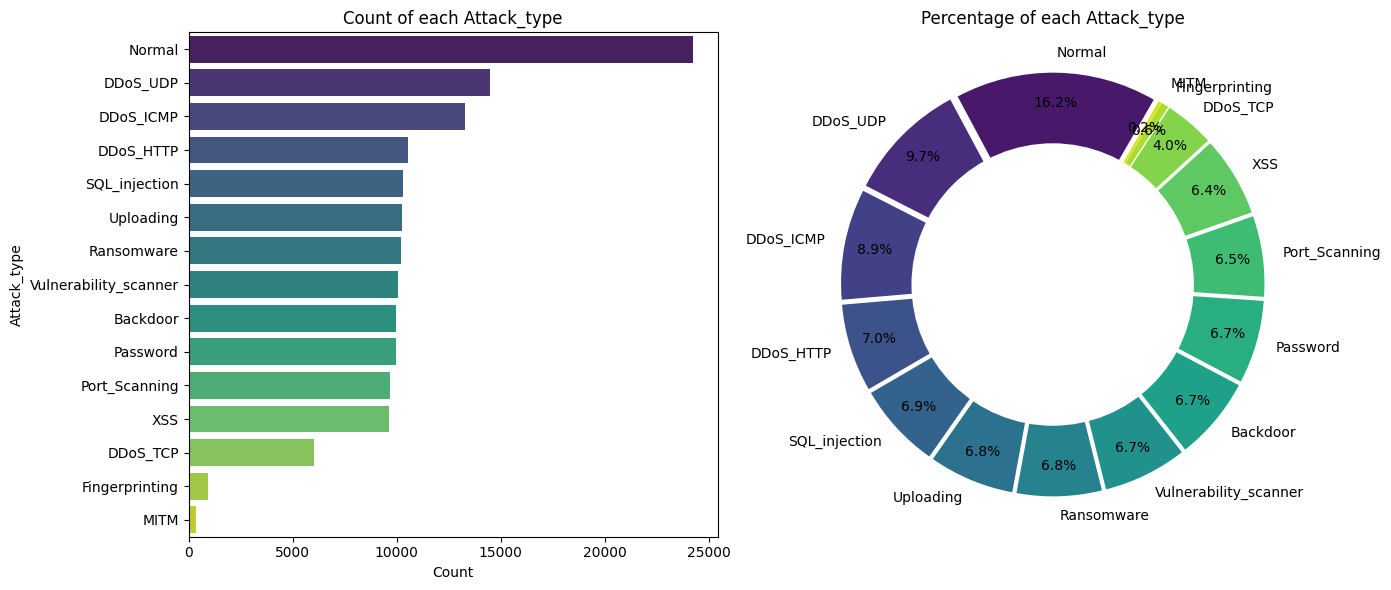

In [600]:
label_col = "Attack_type"
plot_label_distribution(df, label_col)

## 4 - Saving Data

In [601]:
pd.to_pickle(df, config['processed_path'] / f"{filename}.pkl")